# Parte 1 — Análise Exploratória com APIs Externas

Use as APIs públicas e análise geoespacial para responder às questões 1-4:

1. Clima e Demanda de Serviços
Usando a Open-Meteo API, investigue a relação entre condições climáticas (temperatura, precipitação) e o volume de chamados do 1746 no Rio de Janeiro no período 2023-2024.

Entregue: Análise de correlação entre variáveis climáticas e diferentes tipos de chamados, com interpretação sobre quais categorias são mais sensíveis ao clima.

2. Padrões Geoespaciais de Demanda
Analise a distribuição geoespacial dos chamados do 1746 no Rio de Janeiro (2023-2024). Explore padrões territoriais: há concentração em determinadas regiões? Categorias de chamados variam por território?

Entregue: Análise geoespacial com visualizações (mapas, heatmaps), identificação de clusters territoriais e insights sobre desigualdades ou padrões de demanda por região administrativa, bairro ou área de planejamento.

3. Eventos Extremos e Feriados
Investigue como eventos climáticos extremos e feriados (use Public Holiday API) impactam o volume e padrão de chamados no período 2023-2024.

Entregue: Análise comparativa entre dias normais, feriados e eventos extremos (defina seus critérios), incluindo tipos de chamados mais afetados, distribuição territorial e interpretação dos padrões observados.

4. Previsão de Demanda Multidimensional
Construa um modelo de regressão para prever o volume diário de chamados usando features climáticas (temperatura, precipitação), temporais (dia da semana, feriados) e geoespaciais (região, bairro).

Entregue: Dataset agregado, modelo treinado (treino: 2023, teste: 2024), métricas de performance e análise de feature importance. Quais dimensões (clima, tempo, território) são mais relevantes para predição?

## Instalando bibliotecas necessárias

In [288]:
!pip install seaborn
!pip install geopandas
!pip install geobr
!pip install matplotlib

  Using cached geopandas-1.1.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached webencodings-0.5.1-py2.py3-none-any.whl.metadata (2.1 kB)
Using cached geopandas-1.1.0-py3-none-any.whl (338 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 46.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.2 MB/s  0:00:00
Using cached webencodings-0.5.1-py2.py3-none-any.whl (11 kB)
  Attempting uninstall: shapely
    Found existing installation: shapely 2.1.2
    Uninstalling shapely-2.1.2:
      Successfully uninstalled shapely-2.1.2
  Attempting uninstall: geopandas╺━━━━━━━━━━━━━━━━━━━ 3/6 [html5lib]
    Found existing installation: geopandas 1.1.3━━━━━━━━━━━━━━ 3/6 [html5lib]
    Uninstalling geopandas-1.1.3:╺━━━━━━━━━━━━━━━━━━━ 3/6 [html5lib]
      Successfully uninstalled geopandas-1.1.3━━━━━━━━━━━━━━━━ 3/6 [html5lib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [geobr]32m5/6 [geobr]das]


## Importando bibliotecas necessárias

In [294]:
import basedosdados as bd
import pandas as pd
import requests
import seaborn as sns
import geopandas as gpd
import geobr as geobr
import matplotlib.pyplot as plt


### Configurações

In [202]:
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## Base de dados de chamados

### Baixando dados da base

In [206]:
# Junta no BigQuery: só chamados cujo id_bairro existe em dados_mestres.bairro
df_chamados = bd.read_sql(
    """
    SELECT 
      c.*,
      b.nome AS nome_bairro
    FROM 
      `datario.adm_central_atendimento_1746.chamado` AS c
    INNER JOIN `datario.dados_mestres.bairro` AS b
      ON c.id_bairro = b.id_bairro
    WHERE c.data_particao >= '2023-01-01'
      AND c.data_particao <= '2024-12-31'
    ORDER BY RAND()
    LIMIT 500
    """,
    billing_project_id="desafio-pic",
)

Downloading: 100%|██████████|


### Análise de colunas 

In [207]:
df_chamados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 35 columns):
 #   Column                            Non-Null Count  Dtype              
---  ------                            --------------  -----              
 0   id_chamado                        500 non-null    object             
 1   id_origem_ocorrencia              500 non-null    object             
 2   data_inicio                       500 non-null    datetime64[us]     
 3   data_fim                          487 non-null    datetime64[us]     
 4   id_bairro                         500 non-null    object             
 5   id_territorialidade               500 non-null    object             
 6   id_logradouro                     500 non-null    object             
 7   numero_logradouro                 471 non-null    Int64              
 8   id_unidade_organizacional         500 non-null    object             
 9   nome_unidade_organizacional       500 non-null    object         

### Análise de dados duplicados
Nenhum registro duplicado foi encontrado

In [208]:
df_chamados.duplicated().sum()

np.int64(0)

### Análise de dados nulos
Foram encontradas as seguintes colunas com dados nulos:
- numero_logradouro: 28
- longitude: 423
- latitude: 28
- data_alvo_diagnostico: 1000
- data_real_diagnostico: 1000
- justificativa_status: 965

In [209]:
print(
    [
        (col, df_chamados[col].isna().sum())
        for col in df_chamados.columns[df_chamados.isna().any()].tolist()
    ]
)

[('data_fim', np.int64(13)), ('numero_logradouro', np.int64(29)), ('longitude', np.int64(147)), ('latitude', np.int64(147)), ('data_alvo_finalizacao', np.int64(10)), ('data_alvo_diagnostico', np.int64(490)), ('data_real_diagnostico', np.int64(488)), ('tempo_prazo', np.int64(11)), ('prazo_unidade', np.int64(11)), ('prazo_tipo', np.int64(11)), ('justificativa_status', np.int64(460))]


### Análise descritiva dos dados

In [210]:
df_chamados.describe().T

,count,mean,min,25%,50%,75%,max,std
data_inicio,500,2023-12-15 21:43:23.177999,2023-01-02 16:07:20,2023-05-25 15:55:22.750000,2023-12-31 15:31:53,2024-06-22 11:08:04.750000,2024-12-30 14:59:30,NaN
data_fim,487,2024-01-18 00:28:56.174537,2023-01-05 10:02:59,2023-07-02 06:59:09.500000,2024-01-29 10:46:56,2024-07-12 18:47:21.500000,2025-10-14 10:02:38,NaN
numero_logradouro,471.0,503.59448,0.0,40.0,144.0,398.5,23291.0,1668.111262
longitude,353.0,-43.329456,-43.70314,-43.398203,-43.303073,-43.221804,-43.169764,0.13335
latitude,353.0,-22.908979,-23.029048,-22.937275,-22.908125,-22.87988,-22.516353,0.052813
data_alvo_finalizacao,490,2024-01-07 10:01:06.371428,2023-01-09 15:04:00,2023-06-14 11:35:00,2024-01-25 05:14:30,2024-07-16 01:34:15,2025-10-13 16:57:09,NaN
data_alvo_diagnostico,10,2023-06-04 03:10:42,2023-01-20 11:44:00,2023-02-19 20:17:30,2023-03-25 14:18:00,2023-04-18 02:51:45,2024-12-08 09:02:00,NaN
data_real_diagnostico,12,2023-06-17 19:46:44.416666,2023-01-13 14:11:08,2023-02-26 09:58:02.750000,2023-03-15 22:57:35,2023-05-26 09:05:47.750000,2024-12-05 11:02:52,NaN
tempo_prazo,489.0,16.055215,1.0,3.0,8.0,15.0,240.0,33.987447
reclamacoes,500.0,0.026,0.0,0.0,0.0,0.0,1.0,0.159295


### Tratamento de dados nulos
Considerando as análises iniciais, considerei substituir os valores nulos de:
- colunas Int ou Float pela mediana
- colunas de latitude ou longitude pela moda
- colunas de datas não serão alteradas, pois todos os registros são nulos e até o momento não serão usados
- colunas object não serão alteradas, pois até o momento não serão usadas

#### Coluna numero_logradouro

In [211]:
df_chamados["numero_logradouro"] = df_chamados["numero_logradouro"].fillna(
    df_chamados["numero_logradouro"].median().round(0)
)
df_chamados["numero_logradouro"].isna().sum()

np.int64(0)

### Coluna longitude

In [212]:
longitude_moda = df_chamados["longitude"].mode()
if not longitude_moda.empty:
    df_chamados["longitude"] = df_chamados["longitude"].fillna(
        value=float(longitude_moda.iloc[0]),
    )
df_chamados["longitude"].isna().sum()

np.int64(0)

#### Coluna latitude

In [213]:
latitude_moda = df_chamados["latitude"].mode()
if not latitude_moda.empty:
    df_chamados["latitude"] = df_chamados["latitude"].fillna(
        value=float(latitude_moda.iloc[0]),
    )
df_chamados["latitude"].isna().sum()

np.int64(0)

### Tratamento de datas
Para fazer as requisições à API do Open-Meteo é preciso ter a data formatada como "YYYY-MM-dd"

#### Coluna data_inicio

In [214]:
df_chamados["data_inicio"] = pd.to_datetime(df_chamados["data_inicio"]).dt.strftime(
    "%Y-%m-%d"
)
df_chamados["data_inicio"].head()

0    2023-12-04
1    2023-03-28
2    2023-02-05
3    2024-03-14
4    2024-09-02
Name: data_inicio, dtype: object

#### Coluna data_fim

In [215]:
df_chamados["data_fim"] = pd.to_datetime(df_chamados["data_fim"]).dt.strftime(
    "%Y-%m-%d"
)
df_chamados["data_fim"].head()

0    2023-12-04
1    2023-03-29
2    2023-02-05
3    2024-03-15
4    2024-09-04
Name: data_fim, dtype: object

## Baixando dados da API Open-Meteo

### Adicionando informações da API:
- temperatura máxima
- temperatura mínima
- preciptação

In [216]:
from typing import Any


# df = df_chamados.copy()

API_URL = "https://archive-api.open-meteo.com/v1/archive"
DAILY_FIELDS = "temperature_2m_max,temperature_2m_min,precipitation_sum"
TIMEOUT_SECONDS = 20

# Colunas de saída
for col in [
    "temperatura_maxima",
    "temperatura_minima",
    "precipitacao",
]:
    df_chamados[col] = pd.NA


def is_missing_coords(row: pd.Series) -> bool:
    return bool(pd.isna([row["latitude"], row["longitude"]]).any())


def build_weather_params(row: pd.Series) -> dict[str, Any]:
    start_date = pd.Timestamp(row["data_inicio"]).strftime("%Y-%m-%d")
    return {
        "latitude": float(row["latitude"]),
        "longitude": float(row["longitude"]),
        "start_date": start_date,
        "end_date": start_date,
        "daily": DAILY_FIELDS,
        "timezone": "auto",
    }


def fetch_daily_temperatures(
    session: requests.Session,
    params: dict[str, Any],
) -> tuple[list[Any], list[Any], list[Any]]:
    response = session.get(API_URL, params=params, timeout=TIMEOUT_SECONDS)
    response.raise_for_status()

    daily = response.json().get("daily", {})
    max_values = daily.get("temperature_2m_max", [])
    min_values = daily.get("temperature_2m_min", [])
    precipitacao = daily.get("precipitation_sum", [])
    return max_values, min_values, precipitacao


session = requests.Session()
for index, row in df_chamados.iterrows():
    if is_missing_coords(row):
        continue

    params = build_weather_params(row)

    try:
        max_values, min_values, precipitacao = fetch_daily_temperatures(session, params)
    except requests.RequestException:
        continue

    df_chamados.loc[index, "temperatura_maxima"] = (
        max_values[0] if max_values else pd.NA
    )
    df_chamados.loc[index, "temperatura_minima"] = (
        min_values[0] if min_values else pd.NA
    )
    df_chamados.loc[index, "precipitacao"] = precipitacao[0] if precipitacao else pd.NA


df_chamados[
    [
        "temperatura_maxima",
        "temperatura_minima",
        "precipitacao",
    ]
].head(20)

,temperatura_maxima,temperatura_minima,precipitacao
0,29.0,24.2,1.3
1,27.0,23.1,0.4
2,32.5,23.9,0.3
3,29.4,22.0,0.0
4,24.4,20.8,0.6
5,26.4,21.6,0.0
6,35.9,22.6,10.9
7,27.3,23.0,2.1
8,29.1,21.1,0.2
9,30.1,22.9,0.0


### Entrega 1: Análise de correlação entre variáveis climáticas e diferentes tipos de chamados, com interpretação sobre quais categorias são mais sensíveis ao clima.

#### Dados agrupados por data_inicio do chamado e tipo de chamado

In [217]:
df_chamados_agrupados = (
    df_chamados
    .groupby(["tipo", "data_inicio"])
    .agg({
        "tipo": "count", 
        "temperatura_maxima": "median",
        "temperatura_minima": "median",
        "precipitacao": "median"
    })
    .rename(columns={"tipo": "total"})
    .reset_index()
)
df_chamados_agrupados.head()

,tipo,data_inicio,total,temperatura_maxima,temperatura_minima,precipitacao
0,Alimentos e estabelecimentos de ensino,2023-05-22,1,24.4,17.6,0.0
1,Alvará,2023-08-09,1,23.7,19.7,0.9
2,Alvará,2024-06-16,1,29.3,15.3,0.0
3,Arborização,2024-01-17,1,39.1,27.2,0.8
4,Arboviroses,2023-10-08,1,30.3,22.9,0.2


#### Calculando a correlação

In [218]:
resultado = []

for tipo in df_chamados_agrupados["tipo"].unique():
    subset = df_chamados_agrupados[df_chamados_agrupados["tipo"] == tipo]

    if subset["total"].nunique() > 1:
        resultado.append({
            "tipo": tipo,
            "corr_temp_max": subset["total"].corr(subset["temperatura_maxima"]),
            "corr_temp_min": subset["total"].corr(subset["temperatura_minima"]),
            "corr_chuva": subset["total"].corr(subset["precipitacao"]),
        })
df_corr = pd.DataFrame(resultado)
df_corr

,tipo,corr_temp_max,corr_temp_min,corr_chuva
0,Estacionamento irregular,0.147254,0.033249,-0.068496
1,Fiscalização de obras,-0.132074,-0.248413,-0.144885
2,Iluminação Pública,0.269790,0.081789,-0.086093
3,Limpeza de logradouros,-0.074767,0.118114,-0.104984
4,Manejo Arbóreo,0.087266,-0.221020,-0.151443
5,Pavimentação,0.019797,-0.237751,-0.072540
6,Perturbação do sossego,0.026265,-0.120919,-0.126541
7,Remoção Gratuita,-0.122922,-0.174170,-0.069372
8,Sistema Nacional de Regulação (SISREG),-1.000000,1.000000,1.000000
9,Vias públicas,0.191927,0.541559,0.077365


#### Análise de correlação 

Como interpretar as correlações
- menor ou igual a 0 (sem relação)
- 0.3-0.5 (moderada)
- maior que 0.5 (forte)

Interpretações das maiores correlações encontradas

- Chamados relacionados a **Sistema Nacional de Regulação (SISREG)** apresentam correlação positiva de 1 com temperatura mímima e com preciptação
- Chamados relacionados a **Vias Públicas** apresentam correlação positiva de 0.54 com temperatura mínima
- Os demais chamados não possuem correlação significativa com temperatura ou preciptação 

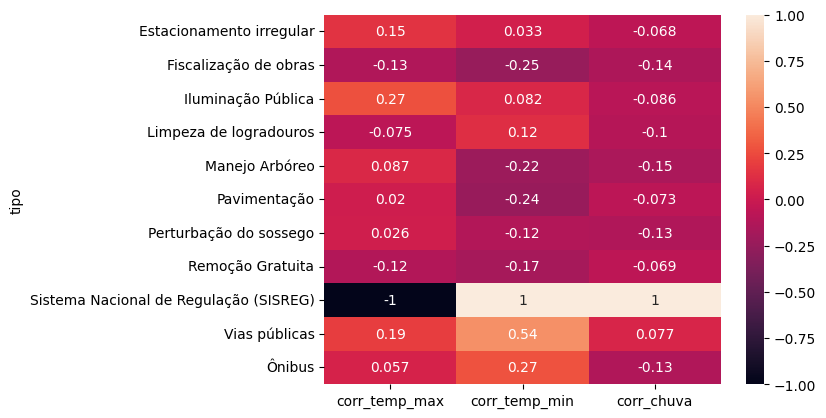

In [219]:
if df_corr.empty:
    print("Sem dados suficientes para calcular correlação por tipo.")
else:
    sns.heatmap(df_corr.set_index("tipo"), annot=True)

### Entrega 2: Análise geoespacial com visualizações (mapas, heatmaps), identificação de clusters territoriais e insights sobre desigualdades ou padrões de demanda por região administrativa, bairro ou área de planejamento.

#### Agrupando dados por nome_bairro, latitude e longitude

In [ ]:
df = df_chamados.copy()
df_agrupado = (
    df.groupby(
        [
            "nome_bairro",
            "latitude",
            "longitude",
        ],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "total"})
)

df_agrupado.sort_values(by="total", ascending=False).head()

,nome_bairro,latitude,longitude,total
72,Campo Grande,-22.912151,-43.203963,18
315,Realengo,-22.912151,-43.203963,7
17,Bangu,-22.912151,-43.203963,7
110,Cidade Nova,-22.912151,-43.203963,6
339,Santa Cruz,-22.912151,-43.203963,6


#### Obtendo os bairros da cidade do Rio de Janeiro, através do geobr, para adicionar ao geo dataframe

In [410]:
bairros = geobr.read_neighborhood(year=2022)
bairros_rj = bairros[bairros["name_muni"] == "Rio de Janeiro"]

#### Obtendo as coordenadas para exibir o total de chamados, por bairro, que tiverem pelo menos 3 chamados

In [ ]:
gdf = gpd.GeoDataFrame(
    df_agrupado,
    geometry=gpd.points_from_xy(df_agrupado["longitude"], df_agrupado["latitude"]),
    crs="EPSG:4326"
)
gdf = gdf.to_crs(bairros_rj.crs)
gdf.columns = gdf.columns.str.strip()
gdf = bairros_rj.merge(
    df_agrupado,
    left_on="name_neighborhood",
    right_on="nome_bairro",
    how="left"
)
gdf = gdf[gdf["total"] >= 3]

#### Mapa da cidade do Rio de Janeiro exibindo o total de chamados, por bairro, através de um mapa de calor
Analisando o mapa, é possível observar que:
- Campo Grande é o bairro com o maior número de chamados, se destacando dos demais
- Santa Cruz, Bangu, Realengo e Cidade Nova possuem uma quantidade de chamados moderada
- Os demais bairros possuem uma quantidade de chamados baixa

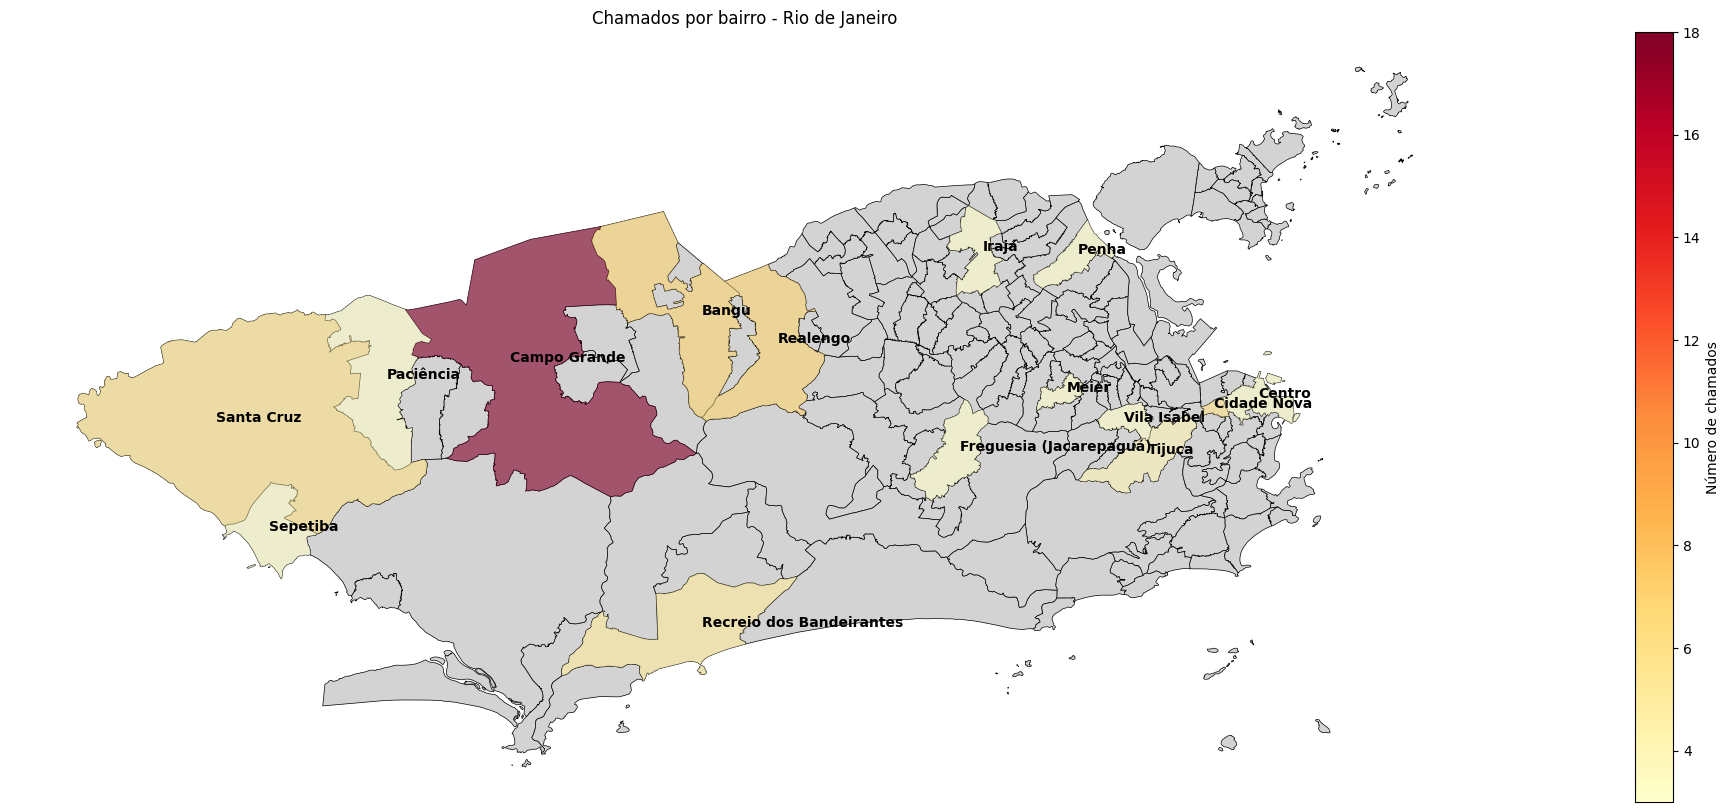

In [ ]:
fig, ax = plt.subplots(figsize=(40, 10))

# Mapa da cidade do Rio de Janeiro
bairros_rj.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.5,
)

top = gdf.sort_values("total", ascending=False)

for idx, row in gdf.iterrows():
    point = row.geometry.representative_point()
    ax.text(point.x, point.y, row["name_neighborhood"], fontsize=10, fontweight="bold")

# Total de chamados por bairro
gdf.plot(
    ax=ax,
    cmap="YlOrRd",
    markersize=10,
    alpha=0.6,
    legend=True,
    column="total",
    legend_kwds={"label": "Número de chamados"},
)

plt.title("Chamados por bairro - Rio de Janeiro")
plt.axis("off")
plt.show()

### Entrega 3: Análise comparativa entre dias normais, feriados e eventos extremos (defina seus critérios), incluindo tipos de chamados mais afetados, distribuição territorial e interpretação dos padrões observados.

#### Baixando os dados de Holiday API e adicionando o nome do feriado ou "Dia Comum" a cada registro de chamados

In [442]:
from datetime import datetime

API_URL = "https://date.nager.at/api/v3/PublicHolidays/{year}/BR"
TIMEOUT_SECONDS = 20


def fetch_data(session: requests.Session, year: int) -> list[dict[str, str]]:
    try:
        response = session.get(API_URL.format(year=year), timeout=TIMEOUT_SECONDS)
        response.raise_for_status()
        return [
            {"date": data["date"], "name": data["localName"]}
            for data in response.json()
        ]
    except requests.exceptions.RequestException as e:
        print(f"Erro ao buscar feriados de {year}: {e}")
        return []


def get_holidays_for_years(
    session: requests.Session, years: list[int]
) -> dict[datetime.date, str]:
    holidays_dict = {}
    for year in years:
        holidays = fetch_data(session, year)
        holidays_dict.update(
            {pd.to_datetime(h["date"]).date(): h["name"] for h in holidays}
        )
    return holidays_dict


session = requests.Session()
feriados = get_holidays_for_years(session, [2023, 2024])

df_chamados["feriado"] = (
    pd.to_datetime(df_chamados["data_inicio"]).dt.date.map(feriados).fillna("Dia Comum")
)

df_chamados[df_chamados["feriado"] != "Dia Comum"][["data_inicio", "feriado"]].head()

,data_inicio,feriado
8,2023-02-20,Carnaval
125,2024-11-02,Dia de Finados
158,2024-09-07,Dia da Independência
174,2024-02-13,Carnaval
182,2024-11-20,Dia da Consciência Negra


### Criando um mapa de calor para visualizar como os top 10 tipos de chamados se comportam em dias comuns e feriados. 
Como os dias comuns são muito maiores em quantidades, em relação aos feriados, os feriados não se destacam no mapa de calor.
Vale uma análise somente dos feriados para identificar qual a data que possui o maior número de chamados por tipo

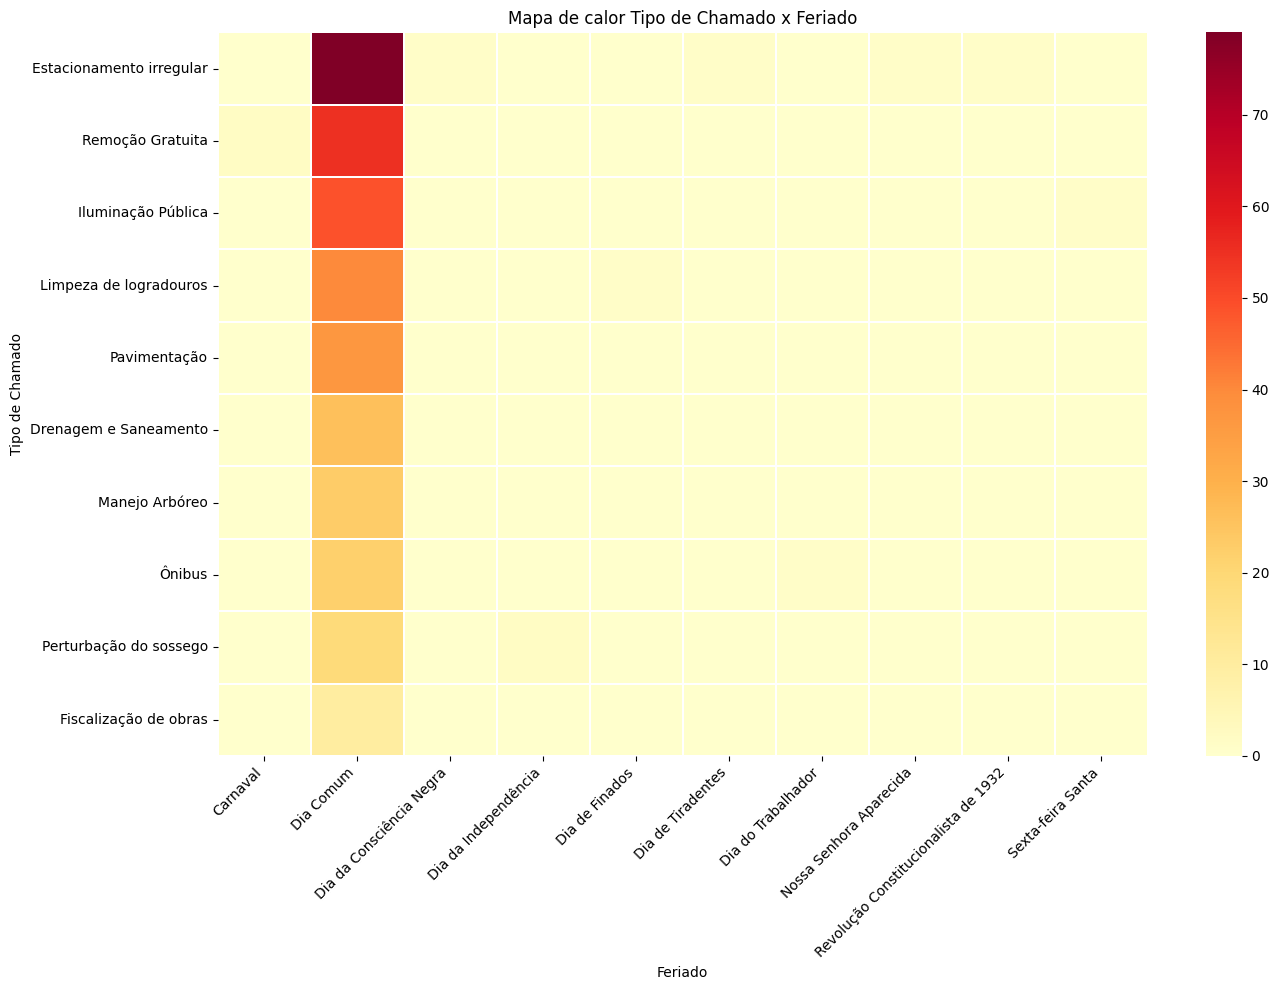

In [ ]:
heatmap_data = pd.crosstab(
    df_chamados["tipo"],
    df_chamados["feriado"],
)

top_tipos = heatmap_data.sum(axis=1).sort_values(ascending=False).head(10).index
heatmap_plot = heatmap_data.loc[top_tipos]

plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_plot,
    cmap="YlOrRd",
    linewidths=0.3,
)
plt.title("Mapa de calor Tipo de Chamado x Feriado")
plt.xlabel("Feriado")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Tipo de Chamado")
plt.tight_layout()
plt.show()


### Criando um mapa de calor para visualizar como os top 10 tipos de chamados se comportam em **feriados**. 
Analisando o mapa de calor é possível observar que:
- As maiores concentrações de chamados ocorreram no **Carnaval** e no **Dia da Independência**
- **Estacionamento irregular** possui maior número de chamados nos em Dia da Consciência Negra, Dia de Tiradentes, Nossa Senhora Aparecida e Revolução Constitucionalista de 1932
- **Pertubação do Sossego** se destacou bastante no Dia da Independência
- **Remoção Gratuita** se destacou bastante no Carnaval
- **Atendimento Social** se destacou no Dia de Finados
- **Iluminação Pública** se destacou na Sexta Feira Santa
- **Limpeza de logradouros** se destacou no Dia de Finados
- **Vigilância Epidemiológica** se destacou no Dia da Consciência Negra
- **Ônibus** se destacou no Dia do Trabalhador

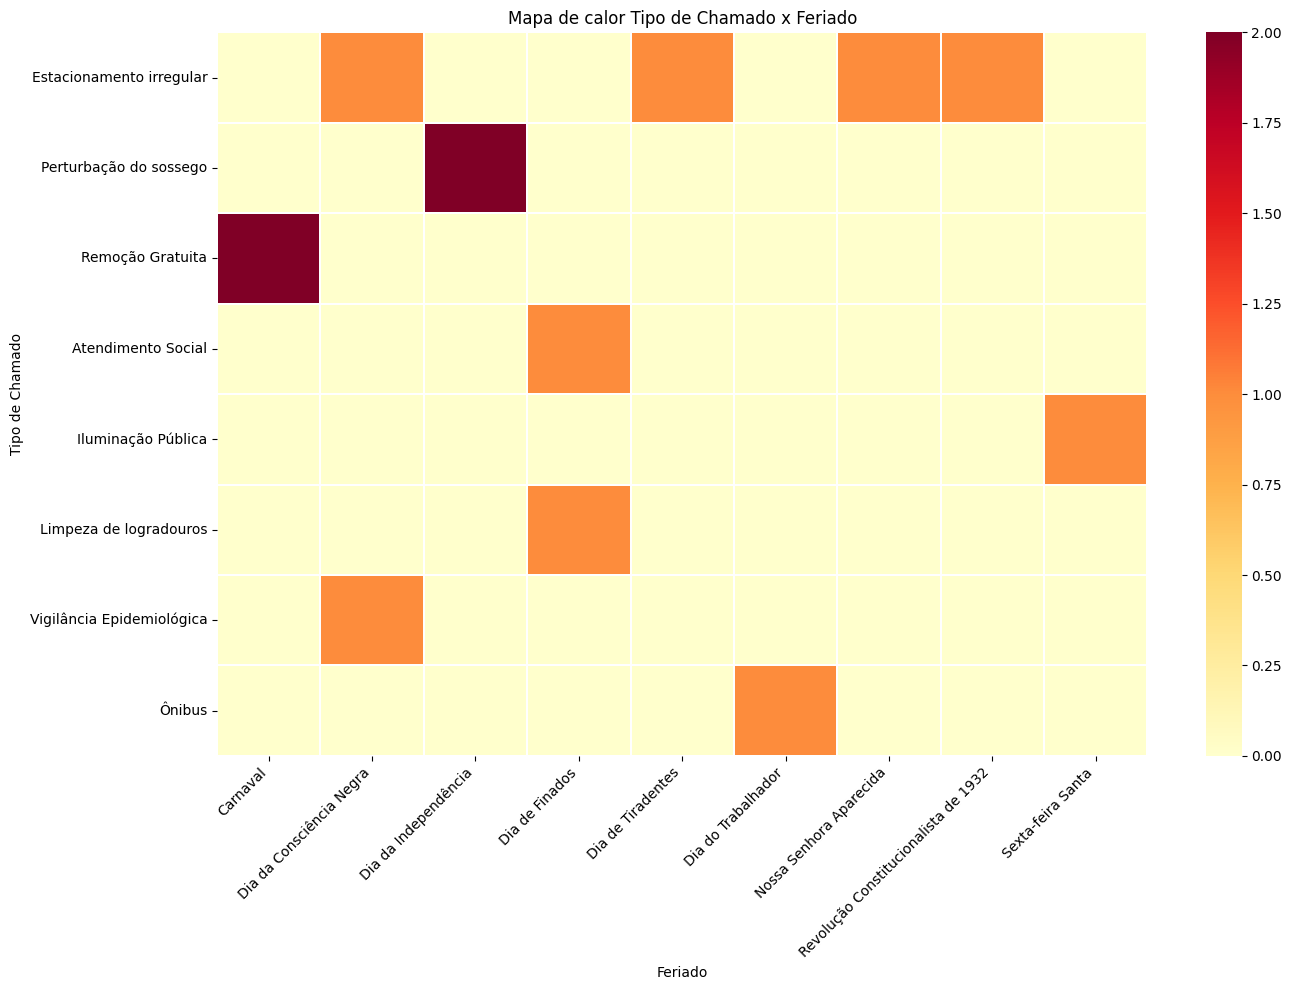

In [447]:
df = df_chamados[df_chamados["feriado"] != "Dia Comum"]

heatmap_data = pd.crosstab(
    df["tipo"],
    df["feriado"],
)

top_tipos = heatmap_data.sum(axis=1).sort_values(ascending=False).head(10).index
heatmap_plot = heatmap_data.loc[top_tipos]

plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_plot,
    cmap="YlOrRd",
    linewidths=0.3,
)
plt.title("Mapa de calor Tipo de Chamado x Feriado")
plt.xlabel("Feriado")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Tipo de Chamado")
plt.tight_layout()
plt.show()
